In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

In [3]:
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import random

# DDPG 실습

https://www.gymlibrary.dev/environments/mujoco/


## Pendulum Environment

https://www.gymlibrary.dev/environments/classic_control/pendulum/

In [4]:
import gymnasium as gym
env = gym.make("Pendulum-v1", render_mode="rgb_array")

In [5]:
# env = gym.make("Pendulum-v1")

num_states = env.observation_space.shape[0]
print("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
print("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

print("Max Value of Action ->  {}".format(upper_bound))
print("Min Value of Action ->  {}".format(lower_bound))

Size of State Space ->  3
Size of Action Space ->  1
Max Value of Action ->  2.0
Min Value of Action ->  -2.0


## Ornstein-Uhlenbeck process에 따라 Noise 계산  

In [6]:

class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        # Formula taken from https://www.wikipedia.org/wiki/Ornstein-Uhlenbeck_process.
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        # Store x into x_prev
        # Makes next noise dependent on current one
        self.x_prev = x
        return x

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)

## Actor-Network, Critic-Network

In [7]:
def get_actor():
    last_init = tf.random_uniform_initializer(minval=-0.003, maxval=0.003)
    inputs = layers.Input(shape=(num_states,))
    out = layers.Dense(256, activation="relu")(inputs)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1, activation="tanh", kernel_initializer=last_init)(out)
    outputs = outputs * upper_bound # (-2 ~ +2)
    model = tf.keras.Model(inputs, outputs)
    return model

def get_critic():
    state_input = layers.Input(shape=(num_states,)) ## State input
    action_input = layers.Input(shape=(num_actions,)) ## Action input
    state_out = layers.Dense(16, activation="relu")(state_input)
    state_out = layers.Dense(32, activation="relu")(state_out)
    action_out = layers.Dense(32, activation="relu")(action_input)
    concat = layers.Concatenate()([state_out, action_out])
    out = layers.Dense(256, activation="relu")(concat)
    out = layers.Dense(256, activation="relu")(out)
    outputs = layers.Dense(1)(out)
    model = tf.keras.Model([state_input, action_input], outputs)
    return model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

 Trainable params: 67,073 (262.00 KB)

 Non-trainable params: 0 (0.00 B)

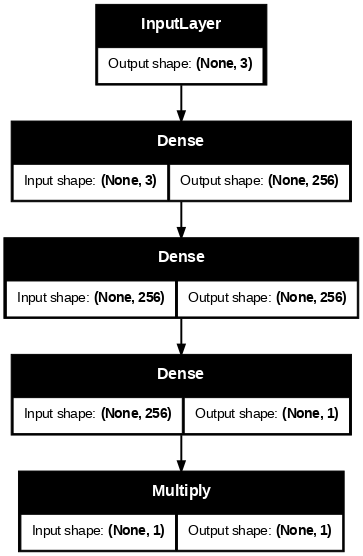

In [8]:
_ = get_actor()
_.summary()
keras.utils.plot_model(_, show_shapes=True,dpi=70)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │         64 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        544 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │         64 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │     16,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        257 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,361 (325.63 KB)

 Trainable params: 83,361 (325.63 KB)

 Non-trainable params: 0 (0.00 B)

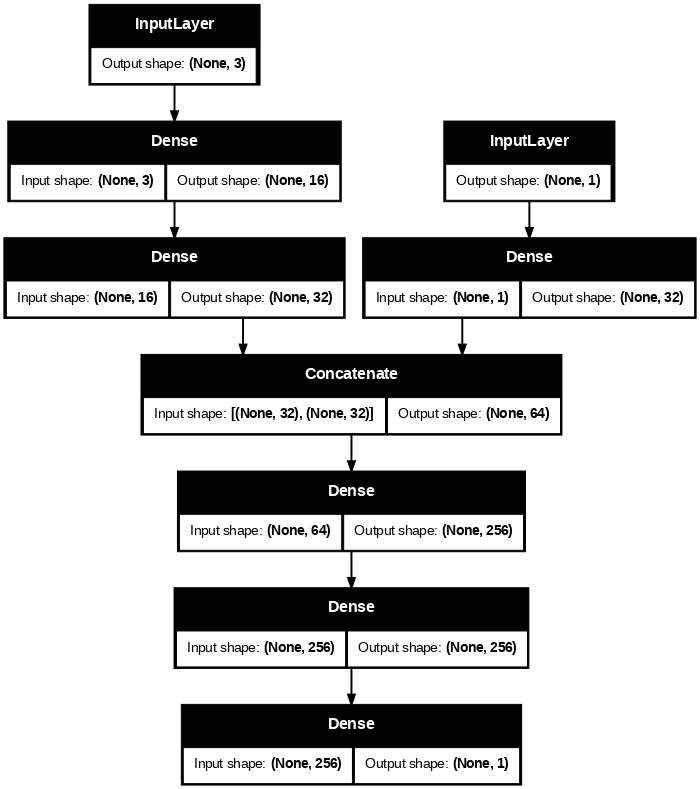

In [9]:
_ = get_critic()
_.summary()
keras.utils.plot_model(_,show_shapes=True,dpi=70)

## DDPG Agent

In [10]:
class DDPG_Agent:
    def __init__(self, buffer_capacity=100000, batch_size=64):
        self.buffer_capacity = buffer_capacity
        self.batch_size = batch_size
        self.buffer_counter = 0  # 저장 횟수
        self.states = np.zeros((self.buffer_capacity, num_states))
        self.actions = np.zeros((self.buffer_capacity, num_actions))
        self.rewards = np.zeros((self.buffer_capacity, 1))
        self.next_states = np.zeros((self.buffer_capacity, num_states))

    def record(self, obs_tuple):  #(s,a,r,s')
        index = self.buffer_counter % self.buffer_capacity
        self.states[index] = obs_tuple[0]
        self.actions[index] = obs_tuple[1]
        self.rewards[index] = obs_tuple[2]
        self.next_states[index] = obs_tuple[3]
        self.buffer_counter += 1

    @tf.function
    def update( self, state_batch, action_batch, reward_batch, next_state_batch,):
        with tf.GradientTape() as tape: # Critic network update
            target_actions = target_actor(next_state_batch, training=True)
            y = reward_batch + gamma * target_critic(
                [next_state_batch, target_actions], training=True )
            critic_value = critic_model([state_batch, action_batch], training=True)
            critic_loss = tf.math.reduce_mean(tf.math.square(y - critic_value))
        critic_grad = tape.gradient(critic_loss, critic_model.trainable_variables)
        critic_optimizer.apply_gradients(
            zip(critic_grad, critic_model.trainable_variables) )

        with tf.GradientTape() as tape: # Actor network update
            actions = actor_model(state_batch, training=True)
            critic_value = critic_model([state_batch, actions], training=True)
            actor_loss = -tf.math.reduce_mean(critic_value) ## (-)
        actor_grad = tape.gradient(actor_loss, actor_model.trainable_variables)
        actor_optimizer.apply_gradients(
            zip(actor_grad, actor_model.trainable_variables) )

    # We compute the loss and update parameters
    def learn(self): # get random samples & update
        record_range = min(self.buffer_counter, self.buffer_capacity)
        batch_indices = np.random.choice(record_range, self.batch_size)
        state_batch = tf.convert_to_tensor(self.states[batch_indices])
        action_batch = tf.convert_to_tensor(self.actions[batch_indices])
        reward_batch = tf.convert_to_tensor(self.rewards[batch_indices])
        reward_batch = tf.cast(reward_batch, dtype=tf.float32)
        next_state_batch = tf.convert_to_tensor(self.next_states[batch_indices])
        self.update(state_batch, action_batch, reward_batch, next_state_batch)

### Soft update

In [11]:
@tf.function
def update_target(target_model, source_model, tau):
    for target_var, source_var in zip(target_model.trainable_variables,\
                                      source_model.trainable_variables):
        target_var.assign(tau * source_var + (1 - tau) * target_var)

### Exploration : action + ϵ  
`policy()` returns an action sampled from our Actor network plus some noise for
exploration.

In [12]:
def policy(state, noise_object):
    sampled_actions = tf.squeeze(actor_model(state))
    noise = noise_object()
    # Adding noise to action
    sampled_actions = sampled_actions.numpy() + noise
    # We make sure action is within bounds
    legal_action = np.clip(sampled_actions, lower_bound, upper_bound)
    return [np.squeeze(legal_action)]

## Training hyperparameters

In [13]:
std_dev = 0.2
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

gamma = 0.99
tau = 0.005

## Actor,Critic,Agent Instanciation

In [14]:
critic_lr = 0.002 ##
actor_lr = 0.001  ##

actor_model = get_actor()
critic_model = get_critic()
target_actor = get_actor()
target_critic = get_critic()
# Traget model weigth <- Main model weight
target_actor.set_weights(actor_model.get_weights())
target_critic.set_weights(critic_model.get_weights())
# Optimizer
critic_optimizer = tf.keras.optimizers.Adam(critic_lr)
actor_optimizer = tf.keras.optimizers.Adam(actor_lr)

agent = DDPG_Agent(2000, 64)  ## buffer_capacity=100000, batch_size=64

## Training Loop  
`policy()` : action sampling  
`learn()` :  train each step  
`update_target()` : TragetNetwork update  

In [15]:
prev_state = env.reset()
p(prev_state)

<<>>:
Type: <class 'tuple'>
Values: (array([-0.8634033 ,  0.5045143 , -0.21094766], dtype=float32), {})


In [16]:
%%time
ep_reward_list = []
avg_reward_list = []
total_episodes = 10 # 100

for ep in range(total_episodes):
    prev_state, _ = env.reset()
    episodic_reward = 0
    cnt = 0
    while True:
        action = policy(prev_state.reshape(1,3), ou_noise)
        state, reward, done, info, _ = env.step(action)
        agent.record((prev_state, action, reward, state))
        episodic_reward += reward

        agent.learn()
        update_target(target_actor, actor_model, tau)
        update_target(target_critic, critic_model, tau)
        cnt += 1
        prev_state = state
        if done or cnt > 500 : break
    ep_reward_list.append(episodic_reward)

    avg_reward = np.mean(ep_reward_list[-10:])
    print("Episode * {} * Avg Reward is ==> {}".format(ep, avg_reward))
    avg_reward_list.append(avg_reward)

Episode * 0 * Avg Reward is ==> -4161.531875198125
Episode * 1 * Avg Reward is ==> -4355.880598356315
Episode * 2 * Avg Reward is ==> -4244.696955156484
Episode * 3 * Avg Reward is ==> -4138.735686652349
Episode * 4 * Avg Reward is ==> -3820.5374017877975
Episode * 5 * Avg Reward is ==> -3592.0664002543162
Episode * 6 * Avg Reward is ==> -3153.310790288757
Episode * 7 * Avg Reward is ==> -2824.513199912387
Episode * 8 * Avg Reward is ==> -2511.3196204347387
Episode * 9 * Avg Reward is ==> -2298.0293477622517
CPU times: user 1min, sys: 1.44 s, total: 1min 1s
Wall time: 1min


In [ ]:
%%time
ep_reward_list = []
avg_reward_list = []
total_episodes = 100

for ep in range(total_episodes):
    prev_state, _ = env.reset()
    episodic_reward = 0
    cnt = 0
    while True:
        action = policy(prev_state.reshape(1,3), ou_noise)
        state, reward, done, info, _ = env.step(action)
        agent.record((prev_state, action, reward, state))
        episodic_reward += reward

        agent.learn()
        update_target(target_actor, actor_model, tau)
        update_target(target_critic, critic_model, tau)
        cnt += 1
        prev_state = state
        if done or cnt > 500 : break
    ep_reward_list.append(episodic_reward)

    avg_reward = np.mean(ep_reward_list[-10:])
    print("Episode * {} * Avg Reward is ==> {}".format(ep, avg_reward))
    avg_reward_list.append(avg_reward)

Episode * 0 * Avg Reward is ==> -3845.0170257184473
Episode * 1 * Avg Reward is ==> -3915.640729865231
Episode * 2 * Avg Reward is ==> -3890.0856371460704
Episode * 3 * Avg Reward is ==> -3912.841820391108
Episode * 4 * Avg Reward is ==> -3884.2070736211763
Episode * 5 * Avg Reward is ==> -3938.006298600719
Episode * 6 * Avg Reward is ==> -3801.1719602738954
Episode * 7 * Avg Reward is ==> -3852.276778804656
Episode * 8 * Avg Reward is ==> -3884.338209965967
Episode * 9 * Avg Reward is ==> -3856.2967899888436
Episode * 10 * Avg Reward is ==> -3804.017444492515
Episode * 11 * Avg Reward is ==> -3794.248573816548
Episode * 12 * Avg Reward is ==> -3792.6254564216556
Episode * 13 * Avg Reward is ==> -3813.5679428577887
Episode * 14 * Avg Reward is ==> -3773.358130200542
Episode * 15 * Avg Reward is ==> -3636.1004139653173
Episode * 16 * Avg Reward is ==> -3714.9228918824024
Episode * 17 * Avg Reward is ==> -3628.3267411299894
Episode * 18 * Avg Reward is ==> -3602.6218420190644
Episode * 1

Wall time: 3min 46s


```python
Episode * 0 * Avg Reward is ==> -1393.6065308283148
Episode * 1 * Avg Reward is ==> -1399.4261465531063
...
Episode * 20 * Avg Reward is ==> -744.0242041713566
Episode * 21 * Avg Reward is ==> -640.0862958070788
..
Episode * 40 * Avg Reward is ==> -299.0683499811841
Episode * 41 * Avg Reward is ==> -286.556930469861
...
Episode * 60 * Avg Reward is ==> -160.28499126077395
Episode * 61 * Avg Reward is ==> -149.5841203256467
...
Episode * 80 * Avg Reward is ==> -333.06615404016287
Episode * 81 * Avg Reward is ==> -344.9272764578158
...
Episode * 98 * Avg Reward is ==> -146.62232475220836
Episode * 99 * Avg Reward is ==> -159.1926263043311
CPU times: user 3min 14s, sys: 7.36 s, total: 3min 22s
Wall time: 3min 19s
```

In [ ]:
plt.figure(figsize=(5,3))
name = 'DDPG scores for Pendulum'
plt.title(f"{name}\n Max Avg Episodic Reward: {max(avg_reward_list):.1f}")
plt.plot(avg_reward_list)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.show()

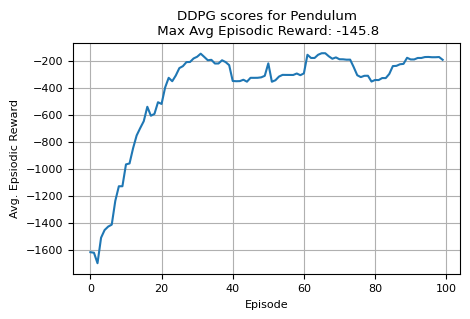

In [ ]:
# Save the weights
# actor_model.save_weights(path+"models/DRL/pendulum_actor.keras")
# actor_model.load_weights(path+"models/DRL/pendulum_actor.keras")

## Evaluation  

In [ ]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
#path =path+"temp/" ####
env_v = wrap_env(env, path=path, name_prefix="DDPG_pendulum")

In [ ]:
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    action = actor_model.predict(state.reshape(1,3),verbose=0)
    state, reward, done, info, _ = env_v.step(action[0])
    if done:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='DDPG_pendulum')

In [ ]:
show_video(path=path,name_prefix='DDPG_pendulum')

/content/gdrive/MyDrive/Colab Notebooks/temp/video/DDPG-episode-0.mp4


# 실습과제   
## 1) Hyper Parameter tuning해 보자  
## 2) 가장 좋은 조건으로 5회 반복하여 변동성을 확인해 보자  

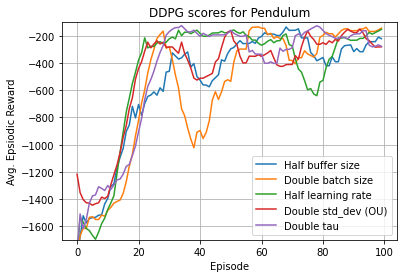

## 실험 1

## Training hyperparameters

In [ ]:
std_dev = 0.2
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

gamma = 0.99
tau = 0.005  ##

## Actor,Critic,Agent Instanciation

In [ ]:
critic_lr = 0.002 ##
actor_lr = 0.001  ##

actor_model = get_actor()
critic_model = get_critic()
target_actor = get_actor()
target_critic = get_critic()
# Traget model weigth <- Main model weight
target_actor.set_weights(actor_model.get_weights())
target_critic.set_weights(critic_model.get_weights())
# Optimizer
critic_optimizer = tf.keras.optimizers.Adam(critic_lr)
actor_optimizer = tf.keras.optimizers.Adam(actor_lr)

agent = DDPG_Agent(2000, 64)  ##

## Training Loop  
`policy()` : action sampling  
`learn()` :  train each step  
`update_target()` : TragetNetwork update  

In [ ]:
%%time
ep_reward_list = []
avg_reward_list = []
total_episodes = 100

for ep in range(total_episodes):
    prev_state = env.reset()
    episodic_reward = 0
    while True:
        tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)

        action = policy(tf_prev_state, ou_noise)
        state, reward, done, info = env.step(action)
        agent.record((prev_state, action, reward, state))
        episodic_reward += reward

        agent.learn()
        update_target(target_actor.variables, actor_model.variables, tau)
        update_target(target_critic.variables, critic_model.variables, tau)

        if done: break
        prev_state = state
    ep_reward_list.append(episodic_reward)

    avg_reward = np.mean(ep_reward_list[-10:])
    print("Episode * {} * Avg Reward is ==> {}".format(ep, avg_reward))
    avg_reward_list.append(avg_reward)

In [ ]:
plt.plot(avg_reward_list)
plt.title('DDPG scores for Pendulum')
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.show()

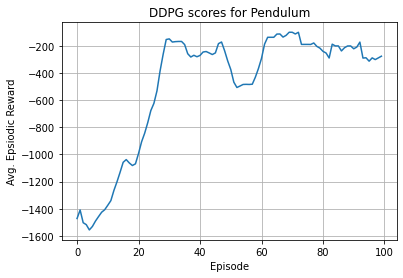